In [57]:
import pandas as pd
from scipy import stats
import numpy as np
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

In [6]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


Shapiro-Wilk Test for Normality

In [71]:
numeric_cols = df.select_dtypes(include=np.number).columns

results = []
for col in numeric_cols:
    data = df[col].dropna()
    shapiro_stat, shapiro_p = stats.shapiro(data)
    skewness = data.skew()
    kurtosis = data.kurt()
    results.append({
        "column": col,
        "n": len(data),
        "skew": round(skewness, 3),
        "kurtosis": round(kurtosis, 3),
        "shapiro_p": round(shapiro_p),
        "likely_normal": shapiro_p > 0.05
    })

normality_summary = pd.DataFrame(results)
print(normality_summary)

       column    n   skew  kurtosis  shapiro_p  likely_normal
0  total_bill  244  1.133     1.218          0          False
1         tip  244  1.465     3.648          0          False
2        size  244  1.448     1.732          0          False
3     tip_pct  244  3.349    27.131          0          False


Visual check — histogram + Q-Q plot side by side, for every column

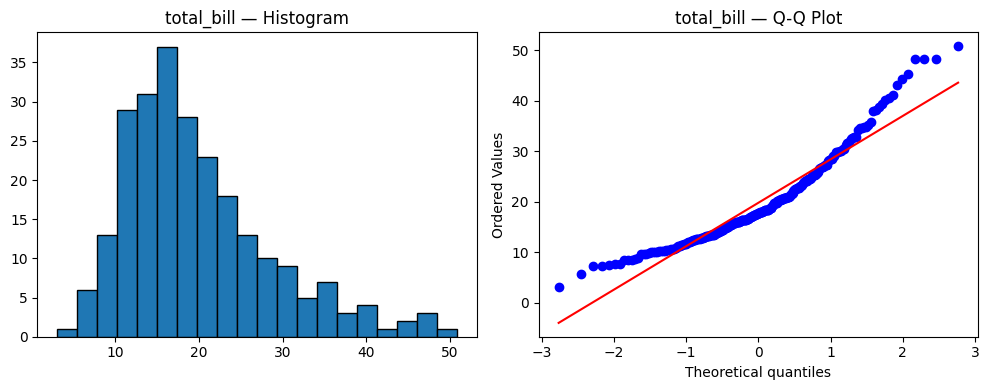

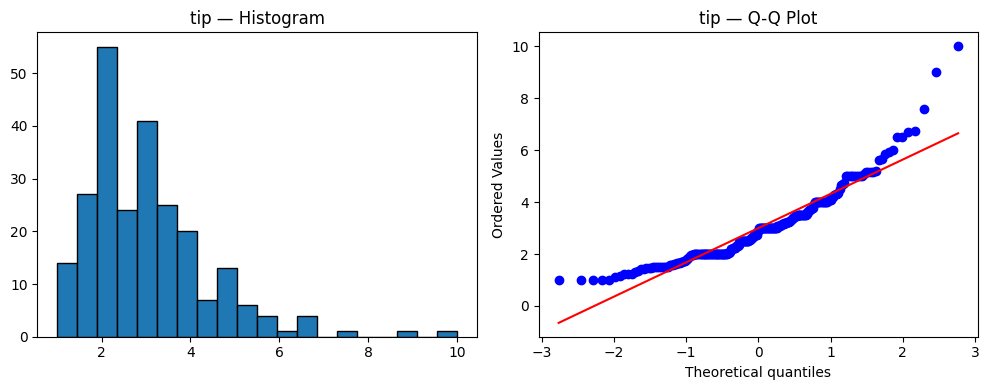

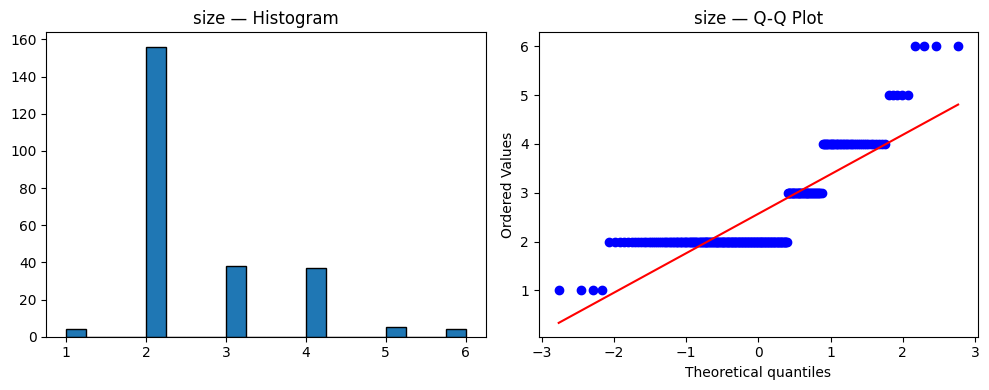

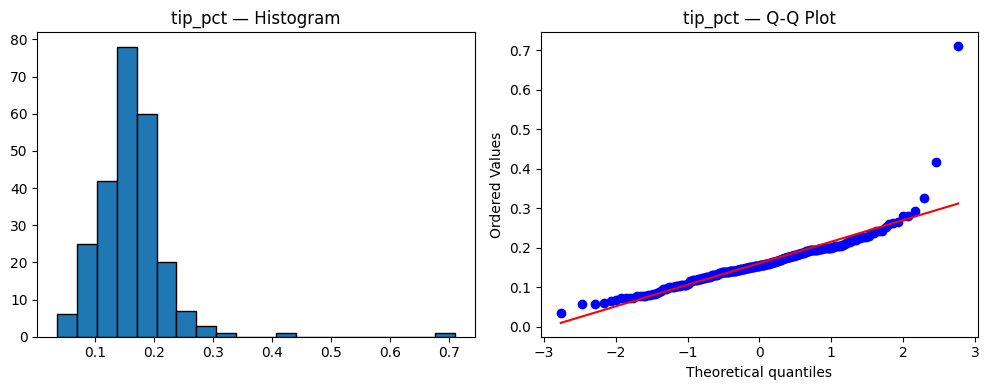

In [70]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(df[col].dropna(), bins=20, edgecolor='black')
    axes[0].set_title(f'{col} — Histogram')

    stats.probplot(df[col].dropna(), dist="norm", plot=axes[1])
    axes[1].set_title(f'{col} — Q-Q Plot')

    plt.tight_layout()
    plt.show()

In [7]:
print(df['tip'].mean(), df['tip'].median(), df['tip'].std())

2.99827868852459 2.9 1.3836381890011822


In [8]:
smokers = df[df['smoker'] == 'Yes']['tip']
non_smokers = df[df['smoker'] == 'No']['tip']

In [11]:
smokers, non_smokers

(56     3.00
 58     1.76
 60     3.21
 61     2.00
 62     1.98
        ... 
 234    3.00
 236    1.00
 237    1.17
 240    2.00
 241    2.00
 Name: tip, Length: 93, dtype: float64,
 0      1.01
 1      1.66
 2      3.50
 3      3.31
 4      3.61
        ... 
 235    1.25
 238    4.67
 239    5.92
 242    1.75
 243    3.00
 Name: tip, Length: 151, dtype: float64)

In [12]:
t_stat, p_value = stats.ttest_ind(smokers, non_smokers)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")

t-statistic: 0.092, p-value: 0.927


#### Fail to reject the null hypothesis. There's no statistically significant difference in tipping behavior between smokers and non-smokers in this dataset.

In [24]:
# 95% confidence interval for mean tip
mean = df['tip'].mean()
sem = stats.sem(df['tip'])
ci = stats.t.interval(0.95, len(df['tip']) - 1, loc=mean, scale=sem)
print(f"95% CI for mean tip: {ci}")

95% CI for mean tip: (2.8237993062818205, 3.172758070767359)


In [25]:
mean, sem, ci

(2.99827868852459, 0.088578358337857, (2.8237993062818205, 3.172758070767359))

In [37]:
# ---------- 1. One-sample t-test ----------
# Is the average tip different from a hypothesized $3?
t_stat, p_value = stats.ttest_1samp(df['tip'], popmean=3)
print(f"[One-sample t-test] t={t_stat:.3f}, p={p_value:.3f}")
print("Conclusion: Fail to reject the null. There's no evidence the average tip differs from $3")

[One-sample t-test] t=-0.019, p=0.985
Conclusion: Fail to reject the null. There's no evidence the average tip differs from $3


In [38]:
# ---------- 2. Independent two-sample t-test (Student's) ----------
smokers = df[df['smoker'] == 'Yes']['tip']
non_smokers = df[df['smoker'] == 'No']['tip']
t_stat, p_value = stats.ttest_ind(smokers, non_smokers)
print(f"[Independent t-test] t={t_stat:.3f}, p={p_value:.3f}")
print("Conclusion: Fail to reject the null. There's no evidence the average tip differs between smokers and non-smokers")

[Independent t-test] t=0.092, p=0.927
Conclusion: Fail to reject the null. There's no evidence the average tip differs between smokers and non-smokers


In [40]:
# ---------- 3. Welch's t-test (use if variances are unequal) ----------
t_stat, p_value = stats.ttest_ind(smokers, non_smokers, equal_var=False)
print(f"[Welch's t-test] t={t_stat:.3f}, p={p_value:.3f}")
print("Conclusion: Fail to reject the null. There's no evidence the average tip differs between smokers and non-smokers")

[Welch's t-test] t=0.092, p=0.927
Conclusion: Fail to reject the null. There's no evidence the average tip differs between smokers and non-smokers


In [ ]:
# ---------- 4. One-way ANOVA ----------
# Does average tip differ across the 4 days?
groups = [df[df['day'] == d]['tip'] for d in df['day'].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"[ANOVA across days] F={f_stat:.3f}, p={p_value:.3f}")
print("Conclusion: Fail to reject the null. There's no evidence the average tip differs across the 4 days.")


[ANOVA across days] F=1.672, p=0.174
Conclusion: Fail to reject the null. There's no evidence the average tip differs across the 4 days.
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   Fri    Sat   0.2584 0.8806 -0.6444 1.1611  False
   Fri    Sun   0.5204 0.4558  -0.394 1.4348  False
   Fri   Thur   0.0367 0.9996 -0.8981 0.9715  False
   Sat    Sun    0.262 0.6204 -0.2977 0.8217  False
   Sat   Thur  -0.2217 0.7679 -0.8141 0.3708  False
   Sun   Thur  -0.4837 0.1724 -1.0938 0.1264  False
---------------------------------------------------


In [43]:
print(groups)

[0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
186    3.50
187    2.00
188    3.50
189    4.00
190    1.50
Name: tip, Length: 76, dtype: float64, 19     3.35
20     4.08
21     2.75
22     2.23
23     7.58
       ... 
238    4.67
239    5.92
240    2.00
241    2.00
242    1.75
Name: tip, Length: 87, dtype: float64, 77     4.00
78     3.00
79     2.71
80     3.00
81     3.40
       ... 
202    2.00
203    2.50
204    4.00
205    3.23
243    3.00
Name: tip, Length: 62, dtype: float64, 90     3.00
91     3.50
92     1.00
93     4.30
94     3.25
95     4.73
96     4.00
97     1.50
98     3.00
99     1.50
100    2.50
101    3.00
220    2.20
221    3.48
222    1.92
223    3.00
224    1.58
225    2.50
226    2.00
Name: tip, dtype: float64]


In [45]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['tip'], groups=df['day'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   Fri    Sat   0.2584 0.8806 -0.6444 1.1611  False
   Fri    Sun   0.5204 0.4558  -0.394 1.4348  False
   Fri   Thur   0.0367 0.9996 -0.8981 0.9715  False
   Sat    Sun    0.262 0.6204 -0.2977 0.8217  False
   Sat   Thur  -0.2217 0.7679 -0.8141 0.3708  False
   Sun   Thur  -0.4837 0.1724 -1.0938 0.1264  False
---------------------------------------------------


In [47]:
# ---------- 5. Mann-Whitney U (non-parametric alt to independent t-test) ----------
u_stat, p_value = stats.mannwhitneyu(smokers, non_smokers)
print(f"[Mann-Whitney U] U={u_stat:.3f}, p={p_value:.3f}")
print("Conclusion: Fail to reject the null. There's no evidence the average tip differs between smokers and non-smokers")

[Mann-Whitney U] U=7163.000, p=0.792
Conclusion: Fail to reject the null. There's no evidence the average tip differs between smokers and non-smokers


In [49]:
# ---------- 6. Kruskal-Wallis (non-parametric alt to ANOVA) ----------
h_stat, p_value = stats.kruskal(*groups)
print(f"[Kruskal-Wallis across days] H={h_stat:.3f}, p={p_value:.3f}")
print("Conclusion: Reject the null. There's evidence the average tip differs across the 4 days.")

[Kruskal-Wallis across days] H=8.566, p=0.036
Conclusion: Reject the null. There's evidence the average tip differs across the 4 days.


In [ ]:
# Checking skew and normality per day tells us WHY the tests (Anova and Kruskal-Wallis) disagree
for day in df['day'].unique():
    day_tips = df[df['day'] == day]['tip']
    print(day, "n=", len(day_tips), "skew=", round(day_tips.skew(), 2),
          "Shapiro p=", round(stats.shapiro(day_tips)[1], 3))

# Levene's across all 4 groups (equal-variance check, extending what we ran for smokers)
groups = [df[df['day'] == d]['tip'] for d in df['day'].unique()]
stat, p_value = stats.levene(*groups)
print(f"[Levene's across days] W={stat:.3f}, p={p_value:.3f}")

Sun n= 76 skew= 0.48 Shapiro p= 0.026
Sat n= 87 skew= 2.0 Shapiro p= 0.0
Thur n= 62 skew= 1.17 Shapiro p= 0.0
Fri n= 19 skew= 0.19 Shapiro p= 0.85
[Levene's across days] W=0.552, p=0.647


In [53]:
# pip install scikit-posthocs

In [55]:
#find out which day is driving it
import scikit_posthocs as sp

dunn_result = sp.posthoc_dunn(df, val_col='tip', group_col='day', p_adjust='bonferroni')
print(dunn_result)

           Fri      Sat       Sun      Thur
Fri   1.000000  1.00000  0.695601  1.000000
Sat   1.000000  1.00000  0.185520  1.000000
Sun   0.695601  0.18552  1.000000  0.041955
Thur  1.000000  1.00000  0.041955  1.000000


"ANOVA and Kruskal-Wallis disagreed, which told me to check my assumptions rather than pick whichever p-value I liked. Tip data is right-skewed, which violates ANOVA's normality assumption and reduces its power, so I trusted the non-parametric result and used Dunn's test to isolate which day was actually different." That's a much stronger answer than either "ANOVA said no difference" or "Kruskal-Wallis said there's a difference" alone.

In [59]:
# ---------- 7. Two-proportion z-test ----------
# Are "generous" tippers (tip > 15% of bill) more common among smokers?
df['tip_pct'] = df['tip'] / df['total_bill']
df['generous'] = df['tip_pct'] > 0.15

n1 = (df['smoker'] == 'Yes').sum()
n2 = (df['smoker'] == 'No').sum()
x1 = df[(df['smoker'] == 'Yes') & df['generous']].shape[0]
x2 = df[(df['smoker'] == 'No') & df['generous']].shape[0]
p1, p2 = x1 / n1, x2 / n2
p_pool = (x1 + x2) / (n1 + n2)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z_stat = (p1 - p2) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
print(f"[Two-proportion z-test] z={z_stat:.3f}, p={p_value:.3f}")
print("Conclusion: Fail to reject the null. There's no evidence that the proportion of generous tippers differs between smokers and non-smokers")


[Two-proportion z-test] z=0.145, p=0.885
Conclusion: Fail to reject the null. There's no evidence that the proportion of generous tippers differs between smokers and non-smokers


In [61]:
# ---------- 8. Chi-square test of independence ----------
# Is sex associated with smoker status?
contingency = pd.crosstab(df['sex'], df['smoker'])
print(contingency)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"[Chi-square independence] chi2={chi2:.3f}, p={p_value:.3f}")
print("Conclusion: Fail to reject the null. There's no evidence that sex is associated with smoker status")

smoker  No  Yes
sex            
Female  54   33
Male    97   60
[Chi-square independence] chi2=0.000, p=1.000
Conclusion: Fail to reject the null. There's no evidence that sex is associated with smoker status


In [62]:
df

,total_bill,tip,sex,smoker,day,time,size,tip_pct,generous
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447,False
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542,True
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587,True
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780,False
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808,False
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.203927,True
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0.073584,False
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.088222,False
242,17.82,1.75,Male,No,Sat,Dinner,2,0.098204,False


In [68]:
# Is sex associated with day?
contingency = pd.crosstab(df['sex'], df['day'])
print(contingency)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"[Chi-square independence] chi2={chi2:.3f}, p={p_value:.3f}")
print("Conclusion: p value is less than 0.05, we reject the null hypothesis. There is evidence that sex is associated with day.")

day     Fri  Sat  Sun  Thur
sex                        
Female    9   28   18    32
Male     10   59   58    30
[Chi-square independence] chi2=13.222, p=0.004
Conclusion: p value is less than 0.05, we reject the null hypothesis. There is evidence that sex is associated with day.


In [73]:
# ---------- 9. Chi-square goodness of fit ----------
# Test whether an observed categorical distribution matches an expected one

# Is customer traffic evenly distributed across the 4 days?
observed = df['day'].value_counts().sort_index()
expected = [len(df) / len(observed)] * len(observed)
print("Observed:", observed)
print("Expected:", expected)
chi2, p_value = stats.chisquare(observed, expected)
print(f"[Chi-square goodness of fit] chi2={chi2:.3f}, p={p_value:.3f}")
print("Conclusion: Reject the null. There's evidence that customer traffic is not evenly distributed across the 4 days.")


Observed: day
Fri     19
Sat     87
Sun     76
Thur    62
Name: count, dtype: int64
Expected: [61.0, 61.0, 61.0, 61.0]
[Chi-square goodness of fit] chi2=43.705, p=0.000
Conclusion: Reject the null. There's evidence that customer traffic is not evenly distributed across the 4 days.


In [76]:
# ---------- 10. Pearson correlation (linear) ----------
r, p_value = stats.pearsonr(df['total_bill'], df['tip'])
print(f"[Pearson correlation] r={r:.3f}, p={p_value:.3f}")
print("Conclusion: Reject the null. There's evidence of a linear correlation between total bill and tip.")

[Pearson correlation] r=0.676, p=0.000
Conclusion: Reject the null. There's evidence of a linear correlation between total bill and tip.


Text(0.5, 1.0, 'Scatter plot of Total Bill vs Tip')

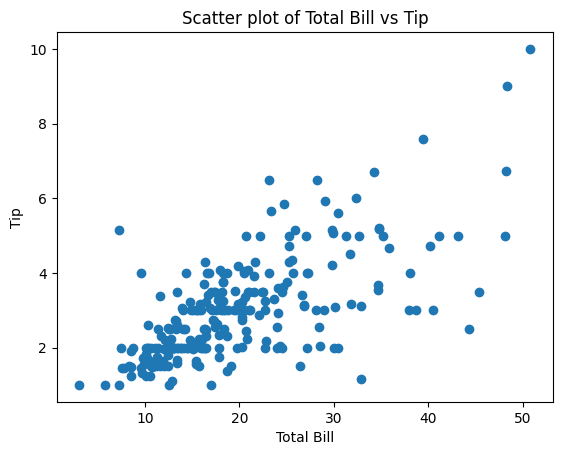

In [82]:
#plot total bill vs tip
x = df['total_bill']
y = df['tip']
plt.scatter(x, y)
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Scatter plot of Total Bill vs Tip')


In [78]:
# ---------- 11. Spearman correlation (monotonic, rank-based) ----------
rho, p_value = stats.spearmanr(df['total_bill'], df['tip'])
print(f"[Spearman correlation] rho={rho:.3f}, p={p_value:.3f}")
print("Conclusion: Reject the null. There's evidence of a monotonic correlation between total bill and tip.")

[Spearman correlation] rho=0.679, p=0.000
Conclusion: Reject the null. There's evidence of a monotonic correlation between total bill and tip.


In [84]:
# ---------- 12. Shapiro-Wilk (normality check) ----------
stat, p_value = stats.shapiro(df['tip'])
print(f"[Shapiro-Wilk on tip] W={stat:.3f}, p={p_value:.3f}")
print("Conclusion: Fail to reject the null. There's no evidence that tip is not normally distributed.")

[Shapiro-Wilk on tip] W=0.898, p=0.000
Conclusion: Fail to reject the null. There's no evidence that tip is not normally distributed.


In [86]:
# ---------- 13. Levene's test (equal variance check) ----------
stat, p_value = stats.levene(smokers, non_smokers)
print(f"[Levene's test] W={stat:.3f}, p={p_value:.3f}")
print("Conclusion: Fail to reject the null. There's no evidence that the variances are significantly different.")

[Levene's test] W=0.021, p=0.886
Conclusion: Fail to reject the null. There's no evidence that the variances are significantly different.


### The 3-question flow:

What type is the outcome? Continuous (like tip) or categorical/binary (like generous)?

How many groups, and are they independent or the same subjects measured twice (paired)?

Is the data roughly normal / is n large? If yes → use the "official" test. If no → drop to its non-parametric twin.

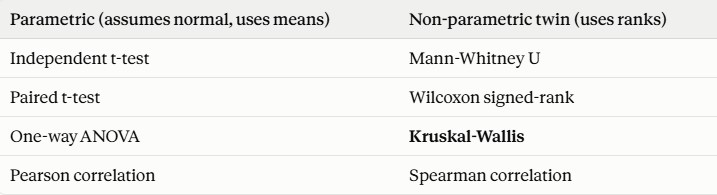